/Users/memeliqu/Data-Science-Project/.venv/bin/python
⏳ Lade CSV … (kann etwas dauern)
✅ Geladen: 4,456,358 Zeilen  |  21 Spalten

1. GRUNDLEGENDE INFOS
code                       object
creator                    object
created_datetime           object
last_modified_datetime     object
product_name               object
packaging_en               object
categories_en              object
labels_en                  object
countries_en               object
ingredients_text           object
nutriscore_score           object
nutriscore_grade           object
nova_group                 object
completeness               object
energy-kcal_100g          float64
fat_100g                   object
saturated-fat_100g         object
sugars_100g               float64
fiber_100g                float64
proteins_100g             float64
salt_100g                 float64
dtype: object

                            count   unique                   top  \
code                      4456358  4456298        

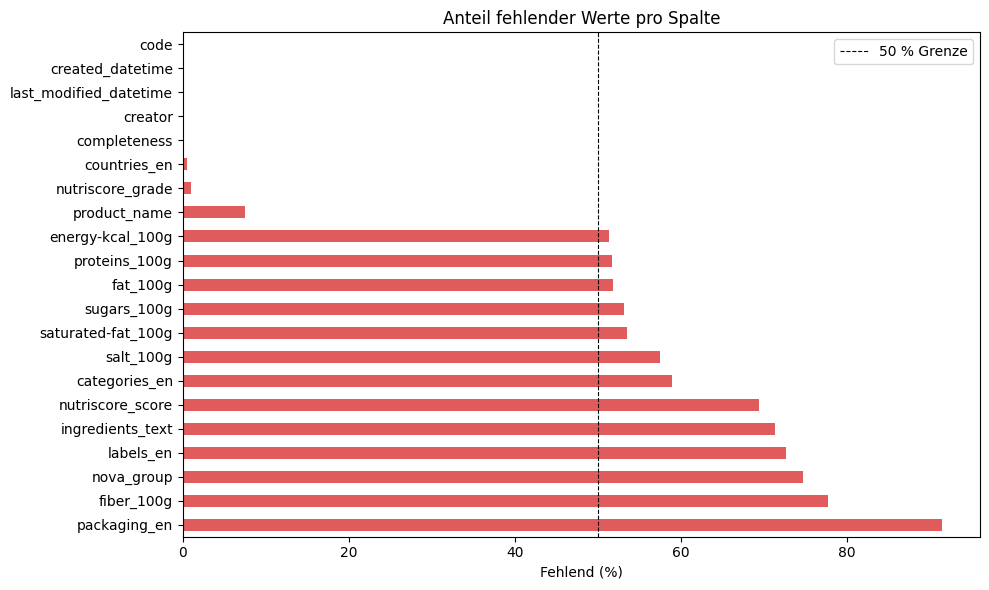

→ Grafik gespeichert: missing_values.png

3. NUTRI-SCORE VERTEILUNG
nutriscore_grade
A    199049
B    157107
C    282739
D    342067
E    382268

Produkte MIT Nutri-Score:  1,363,230 (30.6 %)
Produkte OHNE Nutri-Score: 45,020


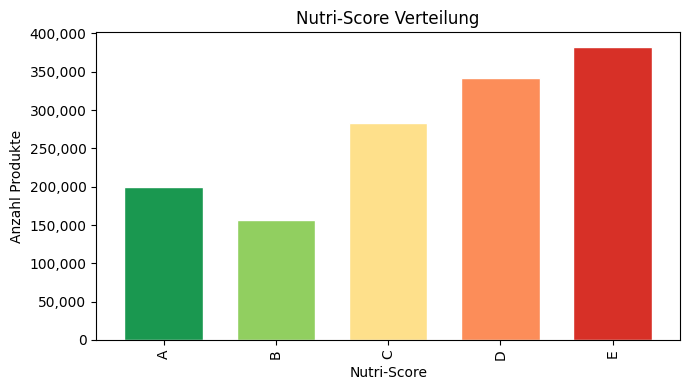


4. NOVA-GRUPPE (Verarbeitungsgrad)
nova_group
1                                                                133823
138                                                                   1
2                                                                 65039
3                                                                208318
4                                                                717523
Italie                                                                1
Made in Germany, Nutriscore, Nutriscore Grade E, en:green-dot         1


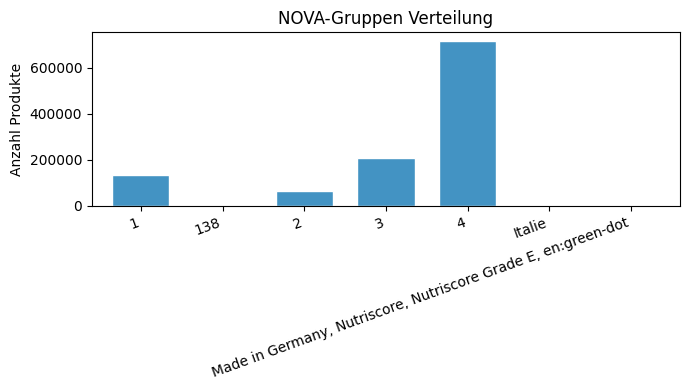


5. TOP 20 LÄNDER (nach Produktanzahl)
countries_en
France            1251334
United States      893005
Germany            402570
Spain              352735
Italy              265370
United Kingdom     183423
Canada             118752
Switzerland        102746
Belgium            100054
Ireland             78352
World               73897
Australia           71868
Netherlands         61769
Japan               37831
Romania             34166
Poland              33804
Brazil              33475
Russia              33291
Norway              25080
Sweden              24350


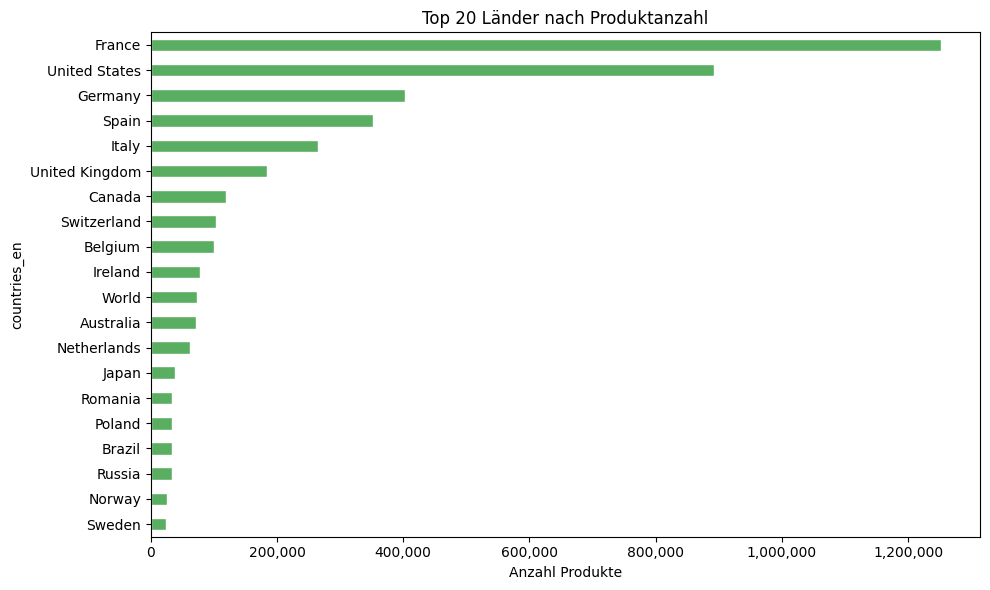


6. NÄHRWERTE – ÜBERBLICK (pro 100g)
       energy-kcal_100g      fat_100g  saturated-fat_100g   sugars_100g    fiber_100g  proteins_100g     salt_100g
count      2.168831e+06  2.145873e+06        2.072058e+06  2.086084e+06  9.889770e+05   2.149529e+06  1.894280e+06
mean       2.106550e+12  2.165350e+19        4.582376e+15  5.631209e+26  4.381646e+06   1.650490e+03  1.179800e+02
std        3.092657e+15  3.171978e+22        6.596168e+18  8.133313e+29  4.357416e+09   1.850611e+06  1.594976e+05
min       -1.138600e+02 -0.000000e+00       -3.990000e+00 -9.000000e-02 -3.330000e+00  -4.760000e+00 -4.500000e-01
25%        1.090000e+02  1.180000e+00        2.000000e-01  6.000000e-01  1.800000e-01   2.000000e+00  1.000000e-01
50%        2.540000e+02  7.300000e+00        1.900000e+00  3.200000e+00  1.670000e+00   6.700000e+00  5.700000e-01
75%        3.940000e+02  2.100000e+01        7.000000e+00  1.440000e+01  3.900000e+00   1.400000e+01  1.400000e+00
max        4.554519e+18  4.646567e+25      

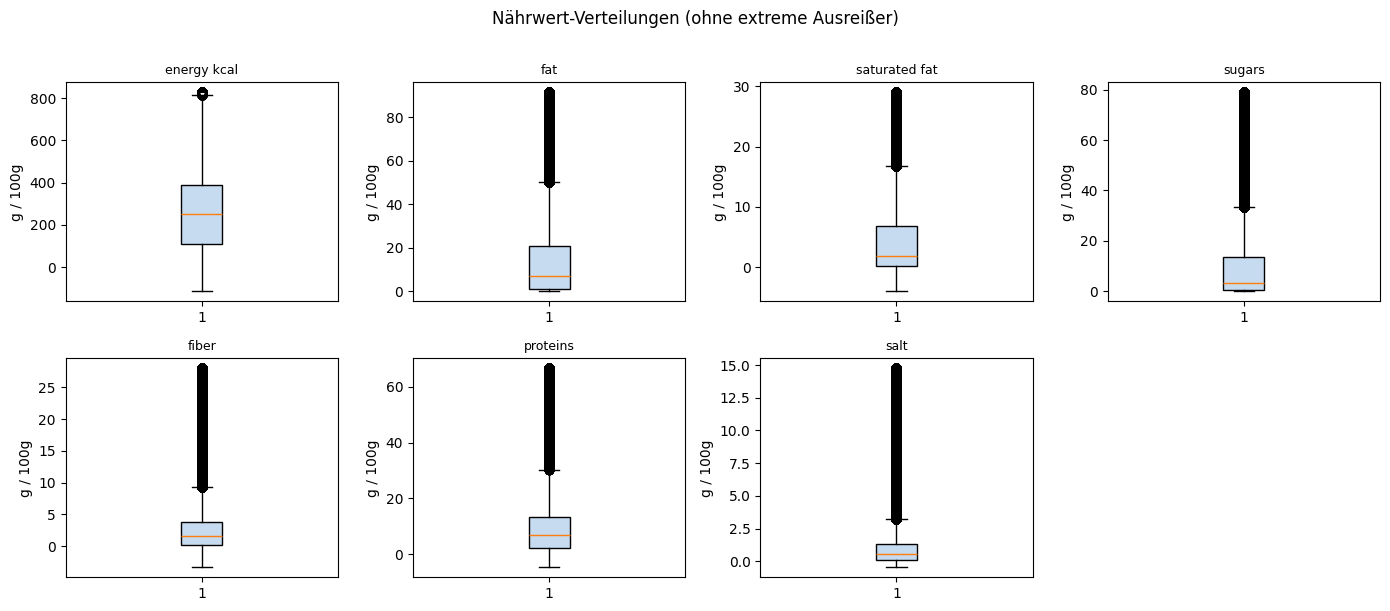


7. ZEITLICHE ENTWICKLUNG (Einträge pro Jahr)
year_created
2012      4397
2013      9883
2014     13209
2015     34774
2016     45713
2017    283006
2018    323480
2019    366277
2020    466603
2021    512296
2022    595994
2023    356808
2024    547719
2025    673829


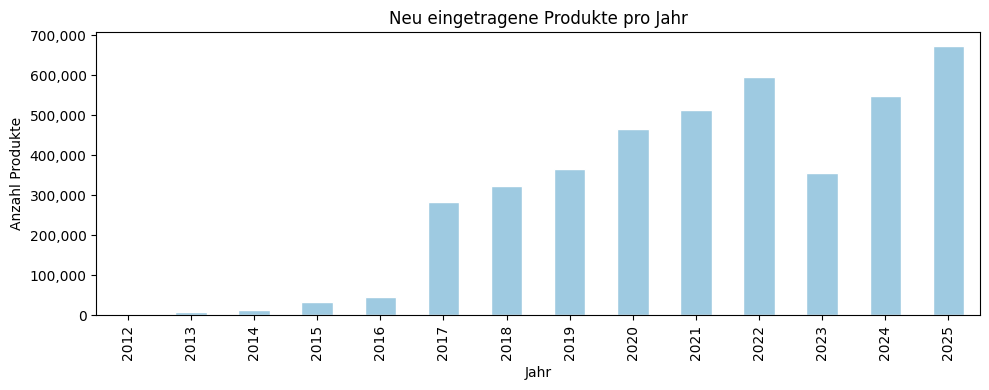


8. VOLLSTÄNDIGKEIT DER EINTRÄGE
count    4456303.000
mean           0.417
std            0.205
min            0.050
25%            0.275
50%            0.375
75%            0.500
max            1.100
Name: completeness, dtype: float64


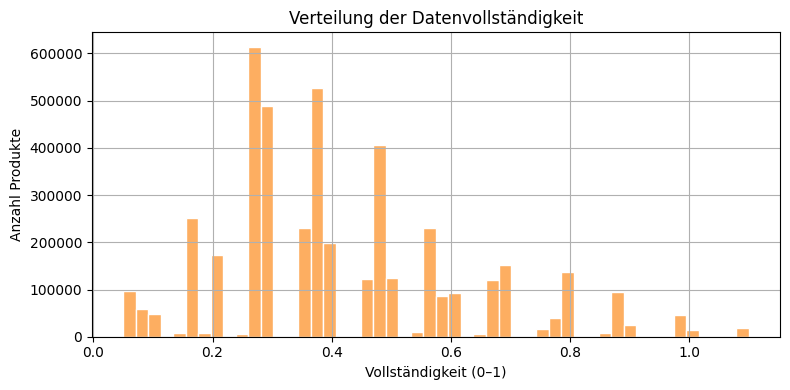


9. ZUSAMMENFASSUNG FÜR MEILENSTEIN 1
Gesamtprodukte:             4,456,358
Produkte mit Name:          4,122,743  (92.5 %)
Produkte mit Nutri-Score:   4,411,338  (99.0 %)
Produkte mit NOVA-Gruppe:   1,124,706  (25.2 %)
Produkte mit Land:          4,433,355  (99.5 %)
Produkte mit Nährwerten:    2,168,831  (48.7 %)
Jahresspanne:            2012 – 2026

Alle Grafiken wurden als PNG gespeichert.
Viel Erfolg beim Meilenstein 1! 🚀


In [3]:
# ============================================================
#  Open Food Facts – Erster Überblick
#  Einfach in ein Jupyter Notebook kopieren und Zelle für Zelle ausführen
# ============================================================
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ── 0. DATEI LADEN ───────────────────────────────────────────
# Pfad anpassen!
CSV_PATH = "en.openfoodfacts.org.products.csv"

# Wir laden zunächst nur die wichtigsten Spalten –
# die volle Datei hat >180 Spalten und mehrere GB.
COLS = [
    "code", "product_name", "countries_en",
    "categories_en", "labels_en",
    "packaging_en",
    "nutriscore_grade", "nutriscore_score",
    "nova_group", "ecoscore_grade",
    "energy-kcal_100g", "fat_100g", "saturated-fat_100g",
    "sugars_100g", "fiber_100g", "proteins_100g", "salt_100g",
    "ingredients_text",
    "created_datetime", "last_modified_datetime",
    "creator", "completeness",
]

print("⏳ Lade CSV … (kann etwas dauern)")
df = pd.read_csv(
    CSV_PATH,
    sep="\t",           # Open Food Facts nutzt Tab als Trennzeichen
    usecols=lambda c: c in COLS,
    low_memory=False,
    on_bad_lines="skip",
)
print(f"✅ Geladen: {df.shape[0]:,} Zeilen  |  {df.shape[1]} Spalten\n")


# ── 1. GRUNDLEGENDE INFOS ────────────────────────────────────
print("=" * 55)
print("1. GRUNDLEGENDE INFOS")
print("=" * 55)
print(df.dtypes)
print()
print(df.describe(include="all").T[["count","unique","top","mean","std","min","max"]])


# ── 2. FEHLENDE WERTE ────────────────────────────────────────
print("\n" + "=" * 55)
print("2. FEHLENDE WERTE (% der Zeilen)")
print("=" * 55)
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing.to_string())

# Visualisierung fehlender Werte
fig, ax = plt.subplots(figsize=(10, 6))
missing.plot(kind="barh", ax=ax, color="#e05c5c")
ax.set_xlabel("Fehlend (%)")
ax.set_title("Anteil fehlender Werte pro Spalte")
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, label="50 % Grenze")
ax.legend()
plt.tight_layout()
plt.savefig("missing_values.png", dpi=150)
plt.show()
print("→ Grafik gespeichert: missing_values.png")


# ── 3. NUTRI-SCORE VERTEILUNG ────────────────────────────────
print("\n" + "=" * 55)
print("3. NUTRI-SCORE VERTEILUNG")
print("=" * 55)
ns = df["nutriscore_grade"].str.upper().value_counts().reindex(["A","B","C","D","E"])
print(ns.to_string())
print(f"\nProdukte MIT Nutri-Score:  {ns.sum():,} ({ns.sum()/len(df)*100:.1f} %)")
print(f"Produkte OHNE Nutri-Score: {df['nutriscore_grade'].isna().sum():,}")

colors_ns = ["#1a9850","#91cf60","#fee08b","#fc8d59","#d73027"]
fig, ax = plt.subplots(figsize=(7, 4))
ns.plot(kind="bar", ax=ax, color=colors_ns, edgecolor="white", width=0.7)
ax.set_title("Nutri-Score Verteilung")
ax.set_xlabel("Nutri-Score")
ax.set_ylabel("Anzahl Produkte")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("nutriscore_distribution.png", dpi=150)
plt.show()


# ── 4. NOVA-GRUPPE ───────────────────────────────────────────
print("\n" + "=" * 55)
print("4. NOVA-GRUPPE (Verarbeitungsgrad)")
print("=" * 55)
nova = df["nova_group"].value_counts().sort_index()
print(nova.to_string())
labels_nova = {1:"1 – Unverarbeitet", 2:"2 – Verarbeitete Zutaten",
               3:"3 – Verarbeitete Lebensmittel", 4:"4 – Ultra-verarbeitet"}
nova.index = [labels_nova.get(i, str(i)) for i in nova.index]
fig, ax = plt.subplots(figsize=(7, 4))
nova.plot(kind="bar", ax=ax, color="#4393c3", edgecolor="white", width=0.7)
ax.set_title("NOVA-Gruppen Verteilung")
ax.set_ylabel("Anzahl Produkte")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("nova_distribution.png", dpi=150)
plt.show()


# ── 5. TOP-LÄNDER ────────────────────────────────────────────
print("\n" + "=" * 55)
print("5. TOP 20 LÄNDER (nach Produktanzahl)")
print("=" * 55)
top_countries = (
    df["countries_en"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(20)
)
print(top_countries.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh", ax=ax, color="#5aae61", edgecolor="white")
ax.set_title("Top 20 Länder nach Produktanzahl")
ax.set_xlabel("Anzahl Produkte")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("top_countries.png", dpi=150)
plt.show()


# ── 6. NÄHRWERTE – ÜBERBLICK ─────────────────────────────────
# ── 6. NÄHRWERTE – ÜBERBLICK ─────────────────────────────────
print("\n" + "=" * 55)
print("6. NÄHRWERTE – ÜBERBLICK (pro 100g)")
print("=" * 55)
nutrients = ["energy-kcal_100g","fat_100g","saturated-fat_100g",
             "sugars_100g","fiber_100g","proteins_100g","salt_100g"]

# Spalten zu Zahlen konvertieren (fehlerhafte Werte werden NaN)
for col in nutrients:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[nutrients].describe().round(2).to_string())

# Boxplots
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(nutrients):
    data = df[col].dropna()
    q99 = data.quantile(0.99)
    axes[i].boxplot(data[data <= q99], vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#c6dbef"))
    axes[i].set_title(col.replace("_100g","").replace("-"," "), fontsize=9)
    axes[i].set_ylabel("g / 100g")
axes[-1].axis("off")
plt.suptitle("Nährwert-Verteilungen (ohne extreme Ausreißer)", y=1.01)
plt.tight_layout()
plt.savefig("nutrients_boxplot.png", dpi=150)
plt.show()


# ── 7. ZEITLICHE ENTWICKLUNG ─────────────────────────────────
print("\n" + "=" * 55)
print("7. ZEITLICHE ENTWICKLUNG (Einträge pro Jahr)")
print("=" * 55)
df["year_created"] = pd.to_datetime(
    df["created_datetime"], errors="coerce"
).dt.year
yearly = df["year_created"].value_counts().sort_index()
yearly = yearly[(yearly.index >= 2012) & (yearly.index <= 2025)]
print(yearly.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
yearly.plot(kind="bar", ax=ax, color="#9ecae1", edgecolor="white")
ax.set_title("Neu eingetragene Produkte pro Jahr")
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl Produkte")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("yearly_entries.png", dpi=150)
plt.show()


# ── 8. VOLLSTÄNDIGKEIT ───────────────────────────────────────
print("\n" + "=" * 55)
print("8. VOLLSTÄNDIGKEIT DER EINTRÄGE")
print("=" * 55)
if "completeness" in df.columns:
    df["completeness"] = pd.to_numeric(df["completeness"], errors="coerce")
    print(df["completeness"].describe().round(3))
    fig, ax = plt.subplots(figsize=(8, 4))
    df["completeness"].dropna().hist(bins=50, ax=ax, color="#fdae61", edgecolor="white")
    ax.set_title("Verteilung der Datenvollständigkeit")
    ax.set_xlabel("Vollständigkeit (0–1)")
    ax.set_ylabel("Anzahl Produkte")
    plt.tight_layout()
    plt.savefig("completeness.png", dpi=150)
    plt.show()


# ── 9. KURZE ZUSAMMENFASSUNG ─────────────────────────────────
print("\n" + "=" * 55)
print("9. ZUSAMMENFASSUNG FÜR MEILENSTEIN 1")
print("=" * 55)
print(f"Gesamtprodukte:          {len(df):>12,}")
print(f"Produkte mit Name:       {df['product_name'].notna().sum():>12,}  ({df['product_name'].notna().mean()*100:.1f} %)")
print(f"Produkte mit Nutri-Score:{df['nutriscore_grade'].notna().sum():>12,}  ({df['nutriscore_grade'].notna().mean()*100:.1f} %)")
print(f"Produkte mit NOVA-Gruppe:{df['nova_group'].notna().sum():>12,}  ({df['nova_group'].notna().mean()*100:.1f} %)")
print(f"Produkte mit Land:       {df['countries_en'].notna().sum():>12,}  ({df['countries_en'].notna().mean()*100:.1f} %)")
print(f"Produkte mit Nährwerten: {df['energy-kcal_100g'].notna().sum():>12,}  ({df['energy-kcal_100g'].notna().mean()*100:.1f} %)")
print(f"Jahresspanne:            {int(df['year_created'].min())} – {int(df['year_created'].max())}")
print()
print("Alle Grafiken wurden als PNG gespeichert.")
print("Viel Erfolg beim Meilenstein 1! 🚀")